# Combined-Temperature Prediction of Thermal Conductivity (`k`) and Effusivity (`eff`)

This notebook pools `30C`, `40C`, `50C`, and `60C` while preserving every trial as
an independent time series and feature row.

It reports three increasingly demanding evaluation protocols:

1. **Pooled held-out repetition** — one repetition number is excluded across all
   materials and temperatures.
2. **Pooled held-out material** — one complete material, at all temperatures and
   repetitions, is excluded.
3. **Held-out temperature** — one complete temperature is excluded.

The first tests repeatability, the second tests unseen-material generalization over
the measured temperature range, and the third tests transfer to an unseen operating
temperature. Their scores answer different questions and must be reported separately.

The numeric temperature is supplied as a predictor. Material identity, `k`, `rho`,
`cp`, and `eff` are never used as predictors.


# 1. Imports and experiment configuration


In [17]:
from pathlib import Path
from itertools import product
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [18]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
RANDOM_STATE = 42

# Post-contact analysis window in seconds.
ANALYSIS_WINDOW = (0.0, 5.0)
EARLY_WINDOW = (0.0, 1.0)
MID_WINDOW = (1.0, 3.0)
LATE_WINDOW = (3.0, 5.0)

# Pre-searched/manual ESN settings. Change these only from training-only evidence.
ESN_RES_SIZE = 50
ESN_LEAK_RATE = 0.1
ESN_INPUT_MAGNITUDE = 1.5
ESN_SPECTRAL_RADIUS = 1.3
ESN_WASHOUT = 0

# Ridge alpha is selected inside each outer training fold.
RIDGE_ALPHAS = (0.1, 1.0, 10.0, 100.0, 1000.0)

cwd = Path.cwd().resolve()
root_candidates = [
    cwd / "data" / "02_preprocessed",
    cwd.parent / "data" / "02_preprocessed",
    cwd.parent.parent / "Warmth-Sensor-Object-Detection" / "data" / "02_preprocessed",
    cwd.parent.parent / "Warmth Sensor Notebook" / "data" / "02_preprocessed",
]
DATA_ROOT = next(
    (
        path for path in root_candidates
        if all((path / temperature).is_dir() for temperature in TEMPERATURE_FOLDERS)
    ),
    None,
)
if DATA_ROOT is None:
    attempted = "\n".join(str(path) for path in root_candidates)
    raise FileNotFoundError(
        "Could not find a preprocessed-data root containing all requested "
        f"temperature folders. Tried:\n{attempted}"
    )

print("Data root:", DATA_ROOT)
print("Temperature folds:", TEMPERATURE_FOLDERS)


Data root: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/data/02_preprocessed
Temperature folds: ('30C', '40C', '50C', '60C')


# 2. Standard material properties and trial loading

The processed CSV values in `k`, `Mass`, `Volume`, `rho`, and `cp` are deliberately
ignored. After loading the sensor data, the notebook overwrites those fields using
the authoritative table below.

`Mass=1 kg` and `Volume=1 m³` are placeholders and can be updated later.


In [19]:
STANDARD_PROPERTIES = {
    "ps_foam":   {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":   {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":      {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":    {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":    {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite":  {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":   {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium":  {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":    {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":      {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum":  {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":    {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood",
    "pdms": "pdms",
    "gypsum": "gypsum",
    "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

standard_table = (
    pd.DataFrame.from_dict(STANDARD_PROPERTIES, orient="index")
    .rename_axis("Material")
    .reset_index()
)
display(standard_table)

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
load_rows = []

for temperature in TEMPERATURE_FOLDERS:
    folder = DATA_ROOT / temperature
    for path in sorted(folder.glob("*.csv")):
        frame = pd.read_csv(path)
        missing = required - set(frame.columns)
        if missing:
            warnings.warn(
                f"Skipping {temperature}/{path.name}; missing {sorted(missing)}"
            )
            continue
        frame["Temperature"] = temperature
        frame["source_file"] = path.name
        frames.append(frame)
        load_rows.append({
            "Temperature": temperature,
            "file": path.name,
            "rows_loaded": len(frame),
        })

if not frames:
    raise ValueError("No valid trial files were found.")

DATA = pd.concat(frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
DATA["Temperature_C"] = pd.to_numeric(
    DATA["Temperature"].str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)
if DATA["Temperature_C"].isna().any():
    raise ValueError("A temperature-folder name could not be converted to Celsius.")

normalized_sample = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
)
DATA["Sample"] = normalized_sample.map(SAMPLE_ALIASES)
unknown_mask = DATA["Sample"].isna()
if unknown_mask.any():
    unknown = sorted(normalized_sample[unknown_mask].unique())
    raise KeyError(f"No standard-property mapping for samples: {unknown}")

# Ignore processed-file property cells and apply one standard table everywhere.
for property_name in ("k", "Mass", "Volume", "rho", "cp"):
    DATA[property_name] = DATA["Sample"].map(
        lambda sample: STANDARD_PROPERTIES[sample][property_name]
    )

# Temperature is required in the ID because material/trial numbers repeat by folder.
DATA["trial_id"] = (
    DATA["Temperature"].astype(str)
    + "__" + DATA["Sample"].astype(str)
    + "_trial_" + DATA["Trial"].astype(str)
)
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA = DATA.sort_values(["Temperature", "trial_id", "Time"]).reset_index(drop=True)

summary = (
    DATA.groupby(["trial_id", "Temperature", "Sample", "Trial"], as_index=False)
    .agg(
        n_timesteps=("Time", "size"),
        k=("k", "first"),
        eff=("eff", "first"),
    )
)
temperature_summary = (
    summary.groupby("Temperature", as_index=False)
    .agg(
        trials=("trial_id", "nunique"),
        materials=("Sample", "nunique"),
        minimum_timesteps=("n_timesteps", "min"),
        maximum_timesteps=("n_timesteps", "max"),
    )
)
print(f"Rows: {len(DATA):,}")
print(f"Unique temperature-specific trials: {DATA['trial_id'].nunique()}")
display(temperature_summary)


,Material,k,Mass,Volume,rho,cp
0,ps_foam,0.034,1.0,1.0,25.0,1400.0
1,pu_foam,0.043,1.0,1.0,30.0,1400.0
2,cork,0.043,1.0,1.0,240.0,1800.0
3,wood,0.150,1.0,1.0,700.0,1700.0
4,pdms,0.150,1.0,1.0,970.0,1460.0
5,gypsum,0.170,1.0,1.0,800.0,1090.0
6,cement,0.290,1.0,1.0,1440.0,750.0
7,graphite,100.000,1.0,1.0,1820.0,710.0
8,bismuth,8.100,1.0,1.0,9780.0,130.0
9,titanium,21.900,1.0,1.0,4506.0,523.0


Rows: 70,480
Unique temperature-specific trials: 336


,Temperature,trials,materials,minimum_timesteps,maximum_timesteps
0,30C,84,14,184,227
1,40C,84,14,200,362
2,50C,84,14,183,404
3,60C,84,14,186,326


# 3. Detect contact and align every trial

The elbow is used only to establish a common time origin. Prediction uses the fixed
0–5 second response after contact. Trials are never aligned using `k` or `eff`.


In [20]:
def find_contact_time(
    trial,
    smooth_window=15,
    polyorder=2,
    threshold_frac=0.30,
    skip_samples=5,
):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")

    work_time = time[skip_samples:]
    work_signal = signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")

    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])


In [21]:
aligned_trials = {}
alignment_rows = []

for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact_time = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    trial["time_from_contact"] = trial["Time"] - contact_time
    start, end = ANALYSIS_WINDOW
    trial = trial[
        trial["time_from_contact"].between(start, end, inclusive="both")
    ].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: too few post-contact samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    alignment_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial),
    })

ALIGNMENT = pd.DataFrame(alignment_rows)
print(f"Aligned trials retained: {len(aligned_trials)}")
display(ALIGNMENT.head())


Aligned trials retained: 336


,trial_id,Temperature,Temperature_C,Sample,Trial,contact_time,n_analysis_samples
0,30C__aluminum_trial_1,30C,30.0,aluminum,1,8.40066,50
1,30C__aluminum_trial_2,30C,30.0,aluminum,2,7.40070,50
2,30C__aluminum_trial_3,30C,30.0,aluminum,3,7.70070,51
3,30C__aluminum_trial_4,30C,30.0,aluminum,4,8.70070,51
4,30C__aluminum_trial_5,30C,30.0,aluminum,5,7.20070,51


## Check several alignments visually


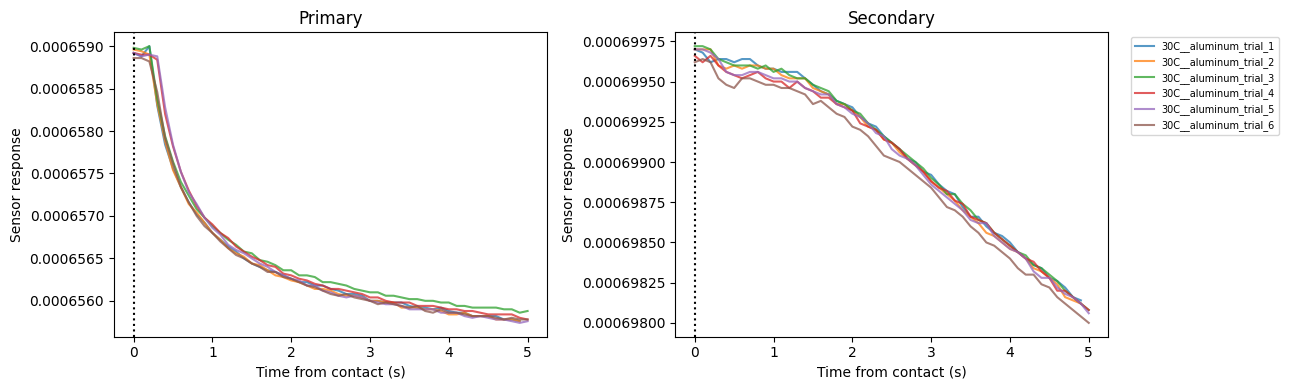

In [22]:
def plot_aligned_trials(material=None, maximum_trials=6):
    selected = list(aligned_trials.values())
    if material is not None:
        selected = [x for x in selected if x["Sample"].iloc[0] == material]
    selected = selected[:maximum_trials]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for trial in selected:
        label = trial["trial_id"].iloc[0]
        axes[0].plot(trial["time_from_contact"], trial["Primary"], alpha=0.75, label=label)
        axes[1].plot(trial["time_from_contact"], trial["Secondary"], alpha=0.75, label=label)
    for ax, title in zip(axes, ["Primary", "Secondary"]):
        ax.axvline(0, color="black", linestyle=":")
        ax.set(xlabel="Time from contact (s)", ylabel="Sensor response", title=title)
    axes[1].legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_aligned_trials(material=ALIGNMENT["Sample"].iloc[0])


# 4. Interpretable thermal-response features


In [23]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= minimum else values.copy()
    )


def _slope(time, values, window):
    mask = (time >= window[0]) & (time <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    result = {}

    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time)
        result[f"{name}_final_change"] = float(change[-1])
        result[f"{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"{name}_response_auc"] = float(np.trapezoid(np.abs(change), time))
        result[f"{name}_early_slope"] = _slope(time, signal, EARLY_WINDOW)
        result[f"{name}_mid_slope"] = _slope(time, signal, MID_WINDOW)
        result[f"{name}_late_slope"] = _slope(time, signal, LATE_WINDOW)
        result[f"{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time))

    # Dimensionless/cross-sensor summaries.
    primary_auc = result["primary_response_auc"]
    result["secondary_primary_auc_ratio"] = (
        result["secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["initial_sensor_difference"] = float(difference[0])
    result["final_sensor_difference"] = float(difference[-1])
    return result


thermal_rows = []
for trial_id, trial in aligned_trials.items():
    features = extract_thermal_features(trial)
    features.update({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "k": float(trial["k"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
    thermal_rows.append(features)

THERMAL_FEATURES = pd.DataFrame(thermal_rows)
print(f"Thermal features: {len(THERMAL_FEATURES.columns) - 7}")
display(THERMAL_FEATURES.head())


Thermal features: 27


,primary_final_change,primary_max_abs_change,primary_response_auc,primary_early_slope,primary_mid_slope,primary_late_slope,primary_max_abs_rate,primary_rate_auc,secondary_final_change,secondary_max_abs_change,...,secondary_primary_auc_ratio,initial_sensor_difference,final_sensor_difference,trial_id,Temperature,Temperature_C,Sample,Trial,k,eff
0,-0.000003,0.000003,0.000013,-0.000002,-3.654261e-07,-1.344399e-07,0.000003,0.000003,-0.000002,0.000002,...,0.225534,-0.000040,-0.000042,30C__aluminum_trial_1,30C,30.0,aluminum,1,237.0,23958.094665
1,-0.000003,0.000003,0.000014,-0.000002,-3.595754e-07,-1.291998e-07,0.000004,0.000003,-0.000002,0.000002,...,0.241267,-0.000040,-0.000042,30C__aluminum_trial_2,30C,30.0,aluminum,2,237.0,23958.094665
2,-0.000003,0.000003,0.000014,-0.000002,-3.389437e-07,-1.112019e-07,0.000003,0.000003,-0.000002,0.000002,...,0.253393,-0.000040,-0.000042,30C__aluminum_trial_3,30C,30.0,aluminum,3,237.0,23958.094665
3,-0.000003,0.000003,0.000013,-0.000002,-3.724766e-07,-1.181206e-07,0.000003,0.000003,-0.000002,0.000002,...,0.243614,-0.000040,-0.000042,30C__aluminum_trial_4,30C,30.0,aluminum,4,237.0,23958.094665
4,-0.000003,0.000003,0.000013,-0.000002,-3.853054e-07,-1.244971e-07,0.000003,0.000003,-0.000002,0.000002,...,0.264204,-0.000041,-0.000042,30C__aluminum_trial_5,30C,30.0,aluminum,5,237.0,23958.094665


# 5. Manual ESN reservoir and trajectory features

The reservoir equation comes from the senior's code, but the logistic `TC` readout is
removed. Instead, each trial's post-contact reservoir trajectory is summarized into
one feature vector for regression.

Input scaling is fitted inside each outer training fold. Therefore ESN features must
also be generated inside each fold.


In [24]:
class ManualReservoir:
    def __init__(
        self,
        res_size=30,
        leak_rate=0.9,
        input_magnitude=1.5,
        spectral_radius=1.3,
        washout=5,
        random_state=42,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(spectral_radius)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 1 + 5)) - 0.5) * self.input_magnitude
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 5:
            raise ValueError("Expected sequence with five input channels.")
        if len(sequence) <= self.washout:
            raise ValueError("Sequence is shorter than the ESN washout.")
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            u = row.reshape(-1, 1)
            x = (
                (1 - self.leak_rate) * x
                + self.leak_rate * np.tanh(
                    self.Win @ np.vstack((1.0, u)) + self.W @ x
                )
            )
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    primary_rate = np.gradient(primary, time)
    secondary_rate = np.gradient(secondary, time)
    return np.column_stack([
        primary, secondary, difference, primary_rate, secondary_rate
    ])


def summarize_states(states):
    result = {}
    summaries = {
        "mean": np.mean(states, axis=0),
        "std": np.std(states, axis=0),
        "final": states[-1],
    }
    for summary_name, values in summaries.items():
        for unit, value in enumerate(values):
            result[f"esn_{summary_name}_{unit}"] = float(value)
    return result


# 6. Visualize ESN state evolution

This section shows how the reservoir responds through the 0–5 second post-contact
window. The visualization uses the same reservoir hyperparameters as regression.

The scaler below is fitted across all trials **only for descriptive visualization**.
It is not reused by cross-validation; evaluation continues to fit scaling exclusively
inside each outer training fold.


In [25]:
def compute_visualization_states(trial_id):
    if trial_id not in aligned_trials:
        raise KeyError(trial_id)

    # Descriptive scaler only—never passed into the evaluation engine.
    visualization_scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(trial) for trial in aligned_trials.values()
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    trial = aligned_trials[trial_id]
    scaled_sequence = visualization_scaler.transform(raw_esn_input(trial))
    states = reservoir.run(scaled_sequence)
    time = trial["time_from_contact"].to_numpy(float)[ESN_WASHOUT:]
    return trial, time, scaled_sequence[ESN_WASHOUT:], states


SELECTED_TRIAL_ID = ALIGNMENT["trial_id"].iloc[0]
selected_trial, state_time, selected_inputs, selected_states = (
    compute_visualization_states(SELECTED_TRIAL_ID)
)

print("Selected trial:", SELECTED_TRIAL_ID)
print("Reservoir-state matrix:", selected_states.shape)


Selected trial: 30C__aluminum_trial_1
Reservoir-state matrix: (50, 50)


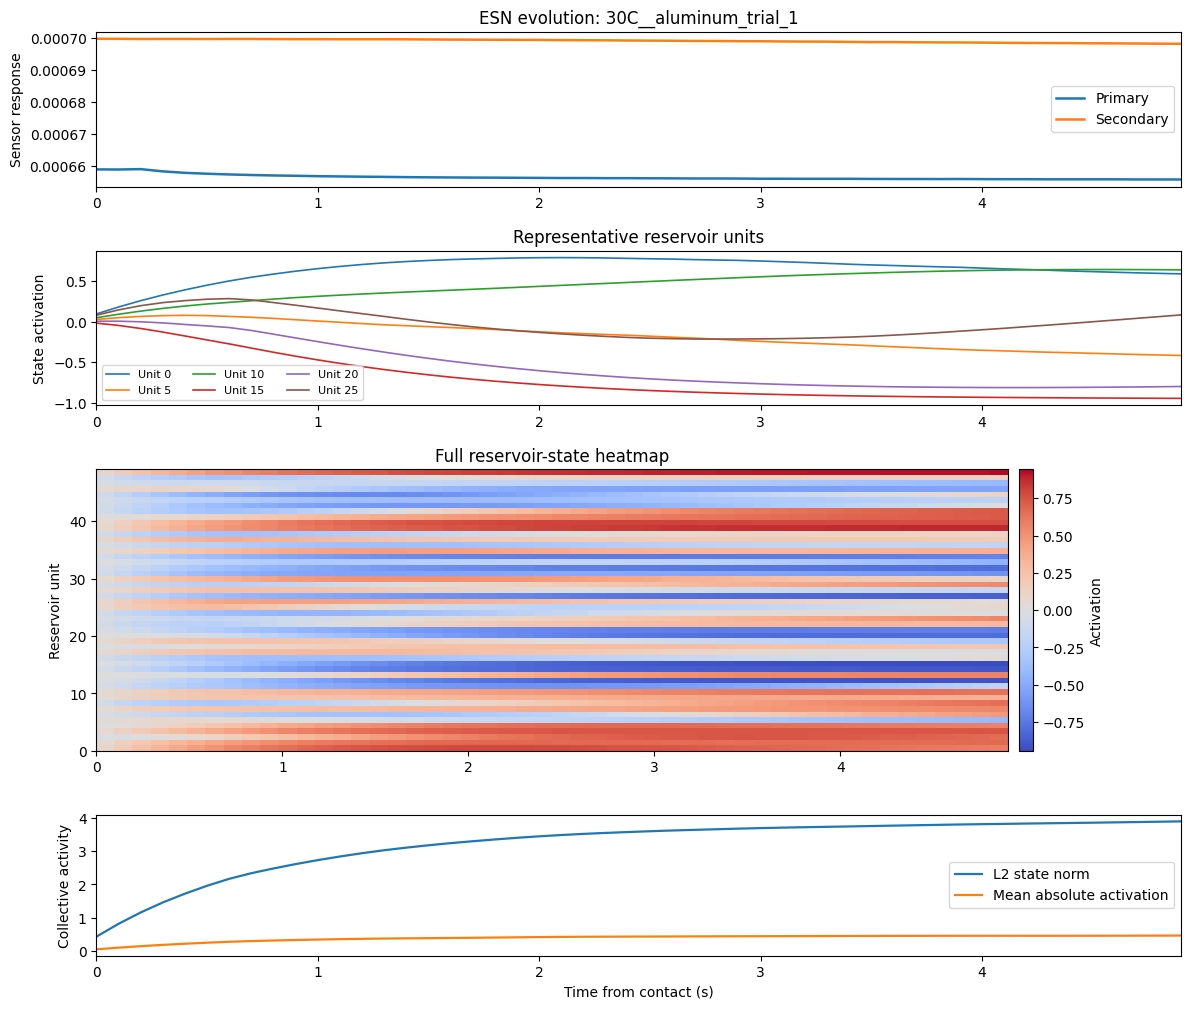

In [26]:
def plot_esn_dynamics(trial_id=SELECTED_TRIAL_ID, units_to_plot=(0, 5, 10, 15, 20, 25)):
    trial, time, scaled_inputs, states = compute_visualization_states(trial_id)

    fig = plt.figure(figsize=(14, 12))
    grid = fig.add_gridspec(4, 1, height_ratios=[1.1, 1.1, 2.0, 1.0], hspace=0.35)

    # Raw sensor response
    ax_inputs = fig.add_subplot(grid[0])
    ax_inputs.plot(
        trial["time_from_contact"], trial["Primary"],
        label="Primary", linewidth=1.8,
    )
    ax_inputs.plot(
        trial["time_from_contact"], trial["Secondary"],
        label="Secondary", linewidth=1.8,
    )
    ax_inputs.set(ylabel="Sensor response", title=f"ESN evolution: {trial_id}")
    ax_inputs.legend(loc="best")

    # Representative reservoir units
    ax_units = fig.add_subplot(grid[1], sharex=ax_inputs)
    valid_units = [unit for unit in units_to_plot if unit < states.shape[1]]
    for unit in valid_units:
        ax_units.plot(time, states[:, unit], label=f"Unit {unit}", linewidth=1.2)
    ax_units.set(ylabel="State activation", title="Representative reservoir units")
    ax_units.legend(ncol=3, fontsize=8)

    # Full state heatmap
    ax_heatmap = fig.add_subplot(grid[2], sharex=ax_inputs)
    limit = np.max(np.abs(states))
    image = ax_heatmap.imshow(
        states.T,
        aspect="auto",
        origin="lower",
        extent=[time.min(), time.max(), 0, states.shape[1] - 1],
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        interpolation="nearest",
    )
    ax_heatmap.set(ylabel="Reservoir unit", title="Full reservoir-state heatmap")
    fig.colorbar(image, ax=ax_heatmap, label="Activation", pad=0.01)

    # Collective reservoir activity
    ax_norm = fig.add_subplot(grid[3], sharex=ax_inputs)
    state_norm = np.linalg.norm(states, axis=1)
    mean_abs_state = np.mean(np.abs(states), axis=1)
    ax_norm.plot(time, state_norm, label="L2 state norm", linewidth=1.6)
    ax_norm.plot(time, mean_abs_state, label="Mean absolute activation", linewidth=1.6)
    ax_norm.set(xlabel="Time from contact (s)", ylabel="Collective activity")
    ax_norm.legend(loc="best")

    plt.show()


plot_esn_dynamics()


## How to interpret the dynamics

- Each heatmap row is one reservoir unit and each column is a post-contact timestep.
- Alternating red and blue patterns show nonlinear units responding with different signs.
- Persistent bands indicate memory of earlier sensor behavior.
- Rapid changes shortly after contact show the reservoir encoding the transient response.
- The state norm summarizes the strength of collective reservoir activation.
- These states are not predictions by themselves; their trajectory summaries become the ESN regression features.


# 7. Leakage-safe regression and metrics


In [27]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    target_range = np.ptp(y_true)
    return {
        "n": len(y_true),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "nrmse_range": rmse / target_range if target_range > 0 else np.nan,
        "r2": (
            r2_score(y_true, y_pred)
            if len(y_true) > 1 and target_range > 0 else np.nan
        ),
        "median_ape_pct": (
            np.median(np.abs((y_true - y_pred) / y_true)) * 100
        ),
    }


def make_regressor(alpha, n_components=None):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
    if n_components is not None:
        steps.append(
            ("pca", PCA(n_components=n_components, random_state=RANDOM_STATE))
        )
    steps.append(("ridge", Ridge(alpha=alpha)))
    base = Pipeline(steps)
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def select_alpha(
    X,
    y,
    groups,
    candidate_alphas=RIDGE_ALPHAS,
    n_components=None,
):
    unique_groups = np.unique(groups)
    if len(unique_groups) < 2:
        raise ValueError("Inner validation requires at least two training groups.")
    n_splits = min(5, len(unique_groups))
    splitter = GroupKFold(n_splits=n_splits)
    rows = []
    for alpha in candidate_alphas:
        errors = []
        for train_idx, valid_idx in splitter.split(X, groups=groups):
            components = n_components
            if components is not None:
                components = min(
                    components,
                    X.shape[1],
                    len(train_idx) - 1,
                )
            model = make_regressor(alpha, n_components=components)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            pred = model.predict(X.iloc[valid_idx])
            pred = np.clip(
                pred,
                y.iloc[train_idx].min(),
                y.iloc[train_idx].max(),
            )
            errors.append(mean_absolute_error(y.iloc[valid_idx], pred))
        rows.append((alpha, float(np.mean(errors))))
    scores = pd.DataFrame(rows, columns=["alpha", "inner_mae"])
    return scores.loc[scores["inner_mae"].idxmin(), "alpha"], scores


# 8. Evaluation engine


# 8. Multi-protocol evaluation engine

All preprocessing that learns from data is fitted inside the outer training fold.
For ESN features, sensor-input scaling is also fold-local.

Inner Ridge selection uses:

- material groups for held-out-repetition evaluation;
- material groups for held-out-material evaluation;
- temperature groups for held-out-temperature evaluation.


In [28]:
PROTOCOL_GROUP_COLUMN = {
    "held_out_repetition": "Trial",
    "held_out_material": "Sample",
    "held_out_temperature": "Temperature",
}


def outer_splits(table, protocol):
    if protocol not in PROTOCOL_GROUP_COLUMN:
        raise ValueError(f"Unknown protocol: {protocol}")
    group_column = PROTOCOL_GROUP_COLUMN[protocol]
    splitter = LeaveOneGroupOut()
    return splitter.split(table, groups=table[group_column])


def inner_group_column(protocol):
    if protocol == "held_out_temperature":
        return "Temperature"
    # Material grouping is conservative and prevents same-material validation
    # leakage when selecting alpha for the other two protocols.
    return "Sample"


def build_esn_feature_table(train_ids, all_ids):
    scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(aligned_trials[trial_id]) for trial_id in train_ids
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        sequence = scaler.transform(raw_esn_input(trial))
        features = summarize_states(reservoir.run(sequence))
        features.update({
            "trial_id": trial_id,
            "Temperature": trial["Temperature"].iloc[0],
            "Temperature_C": float(trial["Temperature_C"].iloc[0]),
            "Sample": trial["Sample"].iloc[0],
            "Trial": int(trial["Trial"].iloc[0]),
            "k": float(trial["k"].iloc[0]),
            "eff": float(trial["eff"].iloc[0]),
        })
        rows.append(features)
    return pd.DataFrame(rows)


def evaluate_feature_family(feature_family, target, protocol):
    metadata_columns = [
        "trial_id", "Temperature", "Temperature_C",
        "Sample", "Trial", "k", "eff",
    ]
    metadata = THERMAL_FEATURES[metadata_columns].copy()
    fold_rows, prediction_rows = [], []
    group_column = PROTOCOL_GROUP_COLUMN[protocol]

    for fold, (train_idx, test_idx) in enumerate(
        outer_splits(metadata, protocol), start=1
    ):
        train_meta = metadata.iloc[train_idx]
        test_meta = metadata.iloc[test_idx]
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()

        if set(train_ids) & set(test_ids):
            raise RuntimeError("Trial leakage detected.")
        if set(train_meta[group_column]) & set(test_meta[group_column]):
            raise RuntimeError(f"{group_column} leakage detected.")

        if feature_family == "thermal":
            fold_features = THERMAL_FEATURES
            n_components = None
        elif feature_family == "esn":
            fold_features = build_esn_feature_table(
                train_ids=train_ids,
                all_ids=train_ids + test_ids,
            )
            n_components = min(10, len(train_ids) - 1)
        else:
            raise ValueError("feature_family must be thermal or esn")

        indexed = fold_features.set_index("trial_id")
        # Temperature_C deliberately remains a numeric predictor.
        excluded = {"Temperature", "Sample", "Trial", "k", "eff"}
        feature_columns = [
            column
            for column in fold_features.select_dtypes(include=np.number).columns
            if column not in excluded
        ]
        X_train = indexed.loc[train_ids, feature_columns].reset_index(drop=True)
        X_test = indexed.loc[test_ids, feature_columns].reset_index(drop=True)
        y_train = indexed.loc[train_ids, target].reset_index(drop=True)
        y_test = indexed.loc[test_ids, target].reset_index(drop=True)
        group_for_inner = inner_group_column(protocol)
        inner_groups = indexed.loc[train_ids, group_for_inner].to_numpy()

        alpha, _ = select_alpha(
            X_train,
            y_train,
            inner_groups,
            n_components=n_components,
        )
        components = n_components
        if components is not None:
            components = min(components, X_train.shape[1], len(X_train) - 1)
        model = make_regressor(alpha, n_components=components)
        model.fit(X_train, y_train)
        raw_pred = model.predict(X_test)
        pred = np.clip(raw_pred, y_train.min(), y_train.max())

        held_out_groups = sorted(
            str(value) for value in test_meta[group_column].unique()
        )
        fold_rows.append({
            "fold": fold,
            "feature_family": feature_family,
            "target": target,
            "protocol": protocol,
            "held_out_group": ", ".join(held_out_groups),
            "selected_alpha": alpha,
            **regression_metrics(y_test, pred),
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": test_ids,
            "Temperature": test_meta["Temperature"].to_numpy(),
            "Temperature_C": test_meta["Temperature_C"].to_numpy(),
            "Sample": test_meta["Sample"].to_numpy(),
            "Trial": test_meta["Trial"].to_numpy(),
            "fold": fold,
            "y_true": y_test.to_numpy(),
            "y_pred": pred,
        }))

    fold_metrics = pd.DataFrame(fold_rows)
    predictions = pd.concat(prediction_rows, ignore_index=True)
    overall = pd.DataFrame([{
        "feature_family": feature_family,
        "target": target,
        "protocol": protocol,
        **regression_metrics(predictions["y_true"], predictions["y_pred"]),
    }])
    return fold_metrics, overall, predictions


# 9. Run all three protocols


In [29]:
PROTOCOLS = (
    "held_out_repetition",
    "held_out_material",
    "held_out_temperature",
)

all_results = []
fold_metrics = {}
predictions = {}

for protocol in PROTOCOLS:
    print(f"Running {protocol}...")
    for family in ("thermal", "esn"):
        for target in ("k", "eff"):
            folds, overall, predicted = evaluate_feature_family(
                family, target, protocol
            )
            all_results.append(overall)
            fold_metrics[(protocol, family, target)] = folds
            predictions[(protocol, family, target)] = predicted

ALL_RESULTS = pd.concat(all_results, ignore_index=True)
display(
    ALL_RESULTS.sort_values(
        ["protocol", "target", "feature_family"]
    ).reset_index(drop=True)
)


Running held_out_repetition...
Running held_out_material...
Running held_out_temperature...


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,esn,eff,held_out_material,336,6377.573042,10670.414265,0.287162,0.093661,65.355620
1,thermal,eff,held_out_material,336,6247.949179,10616.722569,0.285718,0.102759,71.095164
2,esn,k,held_out_material,336,59.938877,117.539744,0.293141,-0.079922,93.761952
3,thermal,k,held_out_material,336,57.097850,114.114960,0.284600,-0.017907,96.020504
4,esn,eff,held_out_repetition,336,5098.794095,9241.406213,0.248705,0.320164,58.045865
5,thermal,eff,held_out_repetition,336,5318.118971,9795.396414,0.263614,0.236213,58.597564
6,esn,k,held_out_repetition,336,51.947050,108.412158,0.270377,0.081289,88.285059
7,thermal,k,held_out_repetition,336,50.849065,107.471211,0.268031,0.097167,83.527044
8,esn,eff,held_out_temperature,336,8436.723532,13448.740530,0.361933,-0.439764,89.701075
9,thermal,eff,held_out_temperature,336,7108.683028,12170.973289,0.327546,-0.179176,79.553557


# 10. Inspect fold-level and aggregated LOMO results

Strict leave-one-material-out produces one true property value inside each individual
material fold, so fold-level R² and test-range NRMSE are mathematically undefined.
Valid LOMO R² and NRMSE are calculated after all out-of-fold predictions are combined.

Two valid aggregated views are reported below:

1. **Trial-level pooled OOF:** all 336 out-of-fold trial predictions.
2. **Material-level OOF:** one mean prediction for each of the 14 held-out materials.

The individual material tables retain MAE, RMSE, and median APE, which remain valid
when the fold target is constant.


In [30]:
# Ordinary fold tables remain appropriate for repetition and temperature protocols.
for protocol in ("held_out_repetition", "held_out_temperature"):
    print(f"\n{protocol.upper()} — ESN → k")
    display(fold_metrics[(protocol, "esn", "k")])
    print(f"{protocol.upper()} — ESN → eff")
    display(fold_metrics[(protocol, "esn", "eff")])


# For each strict LOMO fold, show only metrics defined for a constant true target.
LOMO_FOLD_COLUMNS = [
    "fold",
    "feature_family",
    "target",
    "held_out_group",
    "selected_alpha",
    "n",
    "mae",
    "rmse",
    "median_ape_pct",
]

for target in ("k", "eff"):
    print(f"\nHELD_OUT_MATERIAL — ESN → {target}: per-material errors")
    display(fold_metrics[("held_out_material", "esn", target)][LOMO_FOLD_COLUMNS])


# Valid trial-level LOMO metrics: calculated from every pooled out-of-fold prediction.
LOMO_POOLED_OOF_RESULTS = (
    ALL_RESULTS.loc[ALL_RESULTS["protocol"] == "held_out_material"]
    .sort_values(["target", "feature_family"])
    .reset_index(drop=True)
)

print("\nVALID LOMO METRICS — pooled out-of-fold trial predictions")
display(LOMO_POOLED_OOF_RESULTS)


def aggregate_lomo_by_material(predicted):
    """Reduce 24 temperature/repetition predictions to one prediction per material."""
    return (
        predicted
        .groupby("Sample", as_index=False)
        .agg(
            y_true=("y_true", "first"),
            y_pred=("y_pred", "mean"),
            prediction_sd=("y_pred", "std"),
            n_trials=("y_pred", "size"),
        )
        .sort_values("y_true")
        .reset_index(drop=True)
    )


LOMO_MATERIAL_PREDICTIONS = {}
material_metric_rows = []

for family in ("thermal", "esn"):
    for target in ("k", "eff"):
        material_table = aggregate_lomo_by_material(
            predictions[("held_out_material", family, target)]
        )
        LOMO_MATERIAL_PREDICTIONS[(family, target)] = material_table
        material_metric_rows.append({
            "feature_family": family,
            "target": target,
            "protocol": "held_out_material_mean_prediction",
            **regression_metrics(
                material_table["y_true"],
                material_table["y_pred"],
            ),
        })

LOMO_MATERIAL_RESULTS = pd.DataFrame(material_metric_rows).sort_values(
    ["target", "feature_family"]
).reset_index(drop=True)

print("\nVALID LOMO METRICS — one out-of-fold mean prediction per material")
display(LOMO_MATERIAL_RESULTS)

print("ESN material-level predictions for k")
display(LOMO_MATERIAL_PREDICTIONS[("esn", "k")])

print("ESN material-level predictions for eff")
display(LOMO_MATERIAL_PREDICTIONS[("esn", "eff")])



HELD_OUT_REPETITION — ESN → k


,fold,feature_family,target,protocol,held_out_group,selected_alpha,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,1,esn,k,held_out_repetition,1,100.0,56,49.623212,103.143189,0.257237,0.168420,80.490390
1,2,esn,k,held_out_repetition,2,100.0,56,48.558765,105.194977,0.262354,0.135006,78.944751
2,3,esn,k,held_out_repetition,3,100.0,56,52.514676,109.236874,0.272434,0.067258,84.331869
3,4,esn,k,held_out_repetition,4,100.0,56,53.257826,109.724557,0.273651,0.058911,95.013783
4,5,esn,k,held_out_repetition,5,1000.0,56,54.628488,112.284247,0.280034,0.014491,97.202168
5,6,esn,k,held_out_repetition,6,100.0,56,53.099332,110.610804,0.275861,0.043647,93.159957


HELD_OUT_REPETITION — ESN → eff


,fold,feature_family,target,protocol,held_out_group,selected_alpha,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,1,esn,eff,held_out_repetition,1,100.0,56,4972.940434,8950.667451,0.240881,0.362267,62.629879
1,2,esn,eff,held_out_repetition,2,100.0,56,4557.626551,8723.866427,0.234777,0.394177,57.860528
2,3,esn,eff,held_out_repetition,3,100.0,56,5404.119628,9670.607709,0.260256,0.255550,57.225002
3,4,esn,eff,held_out_repetition,4,0.1,56,5267.289267,9340.078160,0.251360,0.305569,55.155147
4,5,esn,eff,held_out_repetition,5,10.0,56,5123.155088,9221.555784,0.248171,0.323081,57.435980
5,6,esn,eff,held_out_repetition,6,1.0,56,5267.633600,9508.229853,0.255886,0.280340,61.015158



HELD_OUT_TEMPERATURE — ESN → k


...

,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,esn,eff,held_out_material_mean_prediction,14,6055.878476,9803.727483,0.263838,0.234914,74.841978
1,thermal,eff,held_out_material_mean_prediction,14,4939.250962,9167.754330,0.246723,0.330957,72.458551
2,esn,k,held_out_material_mean_prediction,14,59.737398,114.408880,0.285333,-0.023157,636.207917
3,thermal,k,held_out_material_mean_prediction,14,50.960540,109.140225,0.272193,0.068908,435.544151


ESN material-level predictions for k


,Sample,y_true,y_pred,prediction_sd,n_trials
0,ps_foam,0.034,0.494751,0.476704,24
1,cork,0.043,1.073220,1.291027,24
2,pu_foam,0.043,1.327003,1.877955,24
3,pdms,0.150,0.967933,0.904555,24
4,wood,0.150,2.383537,2.540048,24
5,gypsum,0.170,7.507100,8.104849,24
6,cement,0.290,19.728689,53.696672,24
7,bismuth,8.100,66.997326,45.120911,24
8,titanium,21.900,75.969582,46.851845,24
9,iron,80.400,50.610351,29.090501,24


ESN material-level predictions for eff


,Sample,y_true,y_pred,prediction_sd,n_trials
0,ps_foam,34.496377,168.786833,102.320614,24
1,pu_foam,42.497059,275.129882,285.387931,24
2,cork,136.293800,314.869502,258.152941,24
3,gypsum,385.019480,1568.593325,1358.770841,24
4,wood,422.492603,530.942742,587.987155,24
5,pdms,460.901291,238.307803,170.525342,24
6,cement,559.642743,5037.527356,8061.815352,24
7,bismuth,3209.102678,10905.566752,6177.513005,24
8,titanium,7184.035927,12415.287677,7065.235149,24
9,graphite,11367.497526,8490.993222,4616.253495,24


# 11. Actual-versus-predicted comparisons


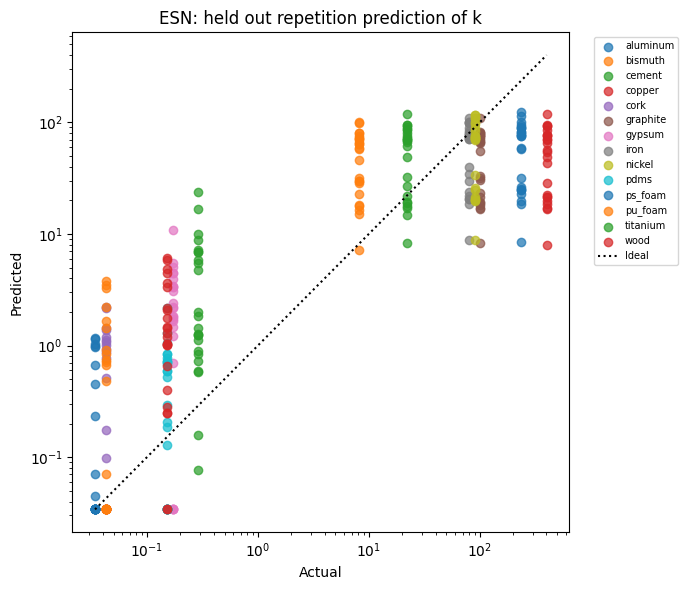

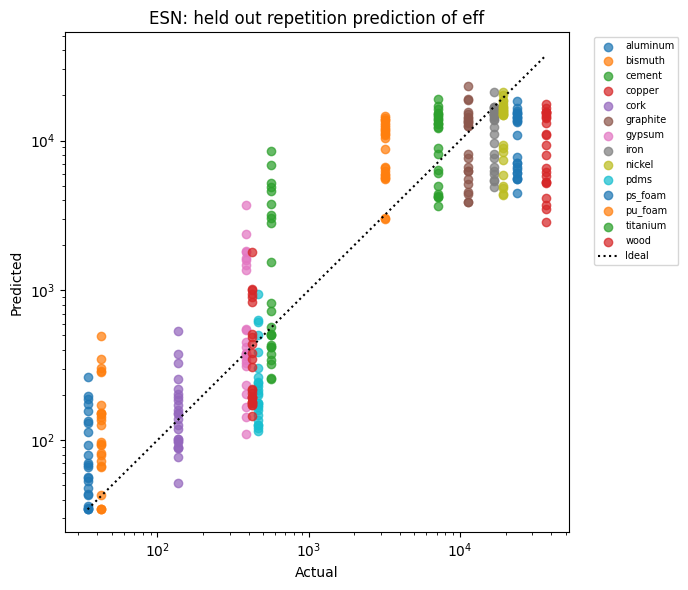

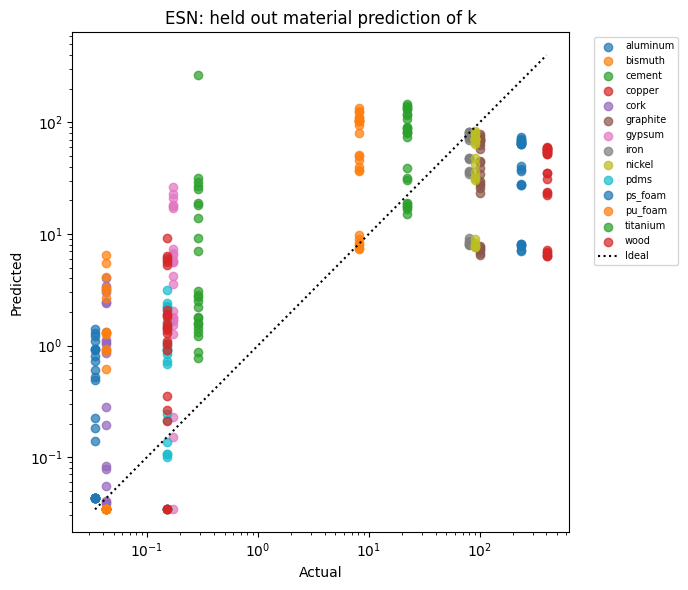

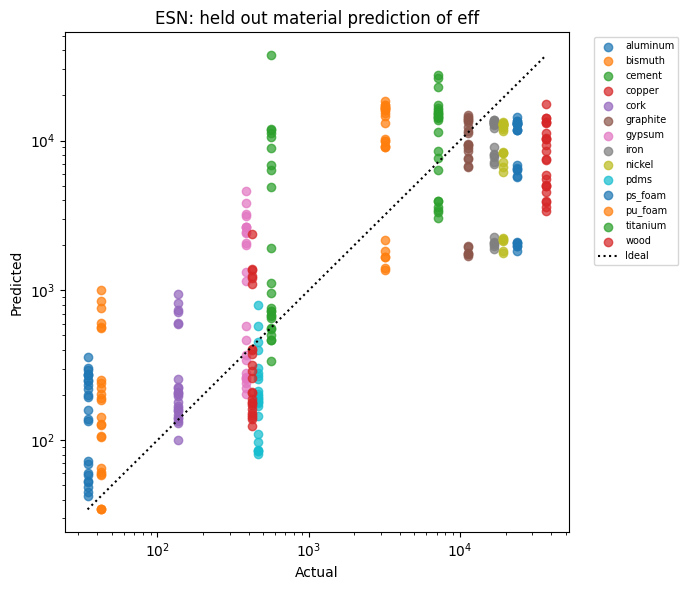

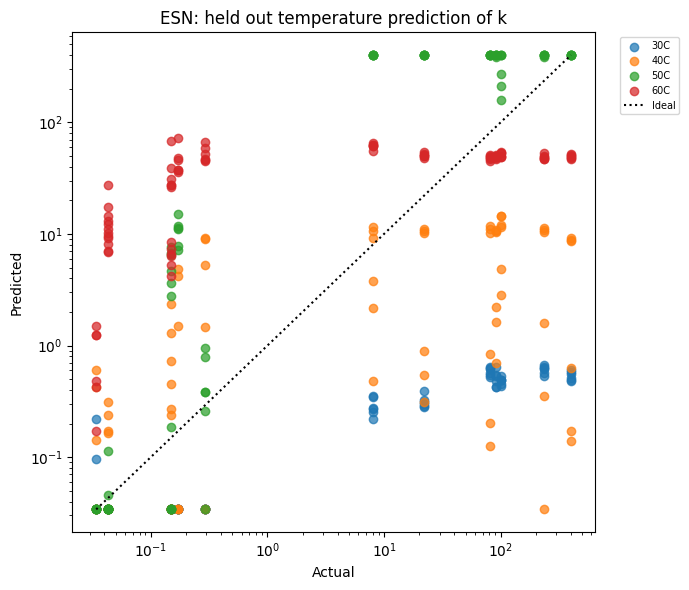

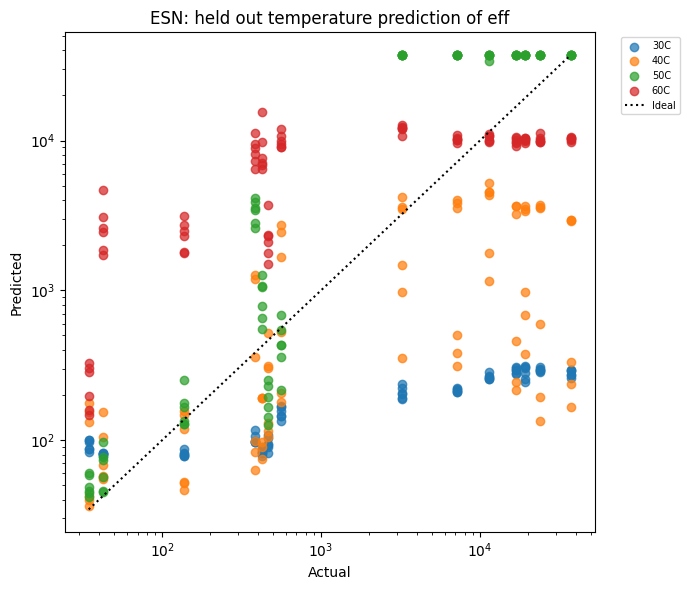

In [31]:
def plot_actual_predicted(predicted, title, color_column):
    shown = predicted[
        (predicted["y_true"] > 0) & (predicted["y_pred"] > 0)
    ].copy()
    fig, ax = plt.subplots(figsize=(7, 6))
    for label, part in shown.groupby(color_column, sort=True):
        ax.scatter(
            part["y_true"], part["y_pred"],
            label=str(label), alpha=0.72,
        )
    low = min(shown["y_true"].min(), shown["y_pred"].min())
    high = max(shown["y_true"].max(), shown["y_pred"].max())
    ax.plot([low, high], [low, high], "k:", label="Ideal")
    ax.set(
        xscale="log", yscale="log",
        xlabel="Actual", ylabel="Predicted", title=title,
    )
    ax.legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    fig.tight_layout()
    plt.show()


for protocol in PROTOCOLS:
    color_column = (
        "Temperature" if protocol == "held_out_temperature" else "Sample"
    )
    for target in ("k", "eff"):
        plot_actual_predicted(
            predictions[(protocol, "esn", target)],
            f"ESN: {protocol.replace('_', ' ')} prediction of {target}",
            color_column,
        )


# 12. Compare protocols directly


In [32]:
comparison = ALL_RESULTS.pivot_table(
    index=["feature_family", "target"],
    columns="protocol",
    values=["r2", "nrmse_range", "mae"],
)
display(comparison)


mae                      \
protocol              held_out_material held_out_repetition   
feature_family target                                         
esn            eff          6377.573042         5098.794095   
               k              59.938877           51.947050   
thermal        eff          6247.949179         5318.118971   
               k              57.097850           50.849065   

                                                 nrmse_range  \
protocol              held_out_temperature held_out_material   
feature_family target                                          
esn            eff             8436.723532          0.287162   
               k                 81.016761          0.293141   
thermal        eff             7108.683028          0.285718   
               k                 66.216109          0.284600   

                                                                \
protocol              held_out_repetition held_out_temperature   
feature_family target                                            
esn            eff               0.248705             0.361933   
               k                 0.270377             0.368541   
thermal        eff               0.263614             0.327546   
               k                 0.268031             0.313308   

                                     r2                      \
protocol              held_out_material held_out_repetition   
feature_family target                                         
esn            eff             0.093661            0.320164   
               k              -0.079922            0.081289   
thermal        eff             0.102759            0.236213   
               k              -0.017907            0.097167   

                                            
protocol              held_out_temperature  
feature_family target                       
esn            eff               -0.439764  
               k                 -0.706902  
thermal        eff               -0.179176  
               k                 -0.233621

# 13. Interpretation rules

- The combined dataset contains 336 independent trial rows: 14 materials ×
  6 repetitions × 4 temperatures.
- Numeric `Temperature_C` is a predictor, so the model can account for the known
  operating condition.
- **Held-out repetition** measures repeatability when the relevant material and
  temperature conditions are represented during training.
- **Held-out material** measures prediction of an unseen material using training
  data spanning the full measured temperature range.
- **Held-out temperature** measures transfer to an operating temperature absent
  from training and is expected to be the hardest.
- Do not combine the three protocols into one score.
- ESN sensor scaling, feature-model scaling, PCA and Ridge fitting occur inside
  the relevant outer training fold.
- Overall metrics are computed from all out-of-fold trial predictions.
- `k` and `eff` are standard-table targets and are not input features.
- Predictions are clipped to the target range observed in the outer training data;
  this prevents extreme extrapolation and must be disclosed in reporting.
